The decision to use Mean Squared Error (MSE) on linear logits for a 3-class classification problem is a fundamental architectural flaw in this exercise. MSE assumes that the underlying errors are normally distributed and penalizes predictions that are "too correct" (e.g., if the target is 1 and the logit is 5, MSE will heavily penalize this, even though a logit of 5 simply indicates high confidence in the correct class).

For classification tasks, the standard and theoretically rigorous approach is to apply a Softmax activation to the logits and compute the Categorical Cross-Entropy loss. This appropriately models a multinomial probability distribution and provides steeper gradients when the model is highly confident but wrong.

However, deriving the gradients for MSE on linear logits provides a mechanical exercise in matrix calculus. The complete implementation and derivation, adhering strictly to the provided parameters, are detailed below.

### A–D: Data Generation, Preprocessing, and Forward Pass

## A. Generate a Synthetic Dataset

The goal is to generate 270 samples (90 per class) from 2D Gaussian clusters. We use the exact parameters specified.

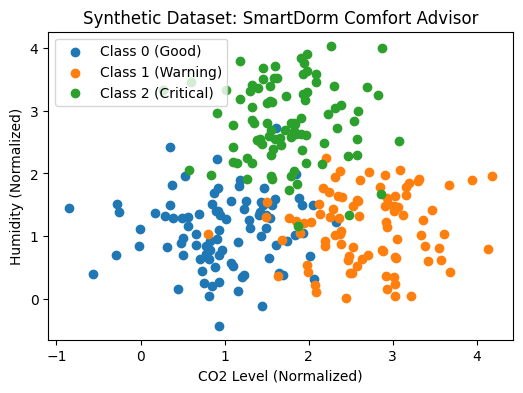

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# A. Generate a Synthetic Dataset
np.random.seed(99)
N_per_class = 90
std = 0.60

# Class means
mu0 = np.array([1.0, 1.0])
mu1 = np.array([2.6, 1.2])
mu2 = np.array([1.7, 2.8])

# Generate clusters
X0 = np.random.randn(N_per_class, 2) * std + mu0
X1 = np.random.randn(N_per_class, 2) * std + mu1
X2 = np.random.randn(N_per_class, 2) * std + mu2

X = np.vstack([X0, X1, X2])
y = np.array([0]*N_per_class + [1]*N_per_class + [2]*N_per_class)

# Plot the dataset
plt.figure(figsize=(6, 4))
plt.scatter(X0[:, 0], X0[:, 1], label='Class 0 (Good)')
plt.scatter(X1[:, 0], X1[:, 1], label='Class 1 (Warning)')
plt.scatter(X2[:, 0], X2[:, 1], label='Class 2 (Critical)')
plt.title("Synthetic Dataset: SmartDorm Comfort Advisor")
plt.xlabel("CO2 Level (Normalized)")
plt.ylabel("Humidity (Normalized)")
plt.legend()
plt.show()

## B. Preprocess & C. Model Definition

We must shuffle the dataset, split it 70/30, and one-hot encode the labels. Then, we initialize a 2-layer network with 5 hidden units (sigmoid) and 3 output units (linear). The weights must be initialized from $\mathcal{N}(0, 0.05)$. Note that a variance of 0.05 means the standard deviation is $\sqrt{0.05}$.

In [5]:
# B. Preprocess
# B.1 Shuffle 
indices = np.random.permutation(len(X))
X_shuffled = X[indices]
y_shuffled = y[indices]

# B.2 Split into train/test = 70/30 
split_idx = int(0.7 * len(X))
X_train, X_test = X_shuffled[:split_idx], X_shuffled[split_idx:]
y_train, y_test = y_shuffled[:split_idx], y_shuffled[split_idx:]

# B.3 One-hot encode labels into Ttrain and Ttest 
T_train = np.eye(3)[y_train]
T_test = np.eye(3)[y_test]

# C. Model Definition
# W1, W2 ~ N(0, 0.05) -> std = sqrt(0.05) 
std_init = np.sqrt(0.05)

# Parameter shapes
W1 = np.random.randn(2, 5) * std_init
b1 = np.zeros((1, 5))
W2 = np.random.randn(5, 3) * std_init
b2 = np.zeros((1, 3))

## D. Forward Pass and Loss

Define the forward computation and print the outputs for the first 3 training samples.

In [6]:
# D. Forward Pass and Loss
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(X, W1, b1, W2, b2):
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)
    Y = np.dot(A1, W2) + b2
    return Z1, A1, Y

# Print for the first 3 training samples
Z1_sample, A1_sample, Y_sample = forward(X_train[:3], W1, b1, W2, b2)
print("--- Forward Pass (First 3 Samples) ---")
print("Z1:\n", Z1_sample)
print("A1:\n", A1_sample)
print("Y:\n", Y_sample)

--- Forward Pass (First 3 Samples) ---
Z1:
 [[ 0.00647523  0.80610794 -0.64758102  0.38550705 -0.19046234]
 [-0.21797027 -0.00300773 -0.33368915 -0.92114714 -0.46820539]
 [-0.06779494  0.18224763 -0.25321484 -0.20510817 -0.19207244]]
A1:
 [[0.5016188  0.69127951 0.34353486 0.59520065 0.45252784]
 [0.44572216 0.49924807 0.41734327 0.28472421 0.38504109]
 [0.48305775 0.54543622 0.43703238 0.44890197 0.45212897]]
Y:
 [[ 0.44694527  0.24156774 -0.06200864]
 [ 0.29067491  0.16408624 -0.02922738]
 [ 0.38558995  0.19206121 -0.04963762]]


## E. Derivation Practice (Backpropagation)
This is the theory part for your written notes.

### E.1 Shapes 
Assuming batch size $N$:
* $X$: (N, 2) 
* $Z_1$: (N, 5) 
* $A_1$: (N, 5) 
* $Y$: (N, 3) 
* $T$: (N, 3) 

### E.2 Start from the loss 
Given $L = \frac{1}{2N}\sum_{i=1}^{N}||Y_i - T_i||^2$, the derivative with respect to $Y$ is:
$$\frac{\partial L}{\partial Y} = \frac{1}{N}(Y - T)$$
*(Matrix shape check: N × 3)*

### E.3 Output layer 
Using $Y = A_1 W_2 + b_2$:
$$\frac{\partial L}{\partial W_2} = A_1^T \frac{\partial L}{\partial Y}$$
*(Shape: 5 × N @ N × 3 = 5 × 3)*

$$\frac{\partial L}{\partial b_2} = \sum_{i=1}^{N} \left(\frac{\partial L}{\partial Y}\right)_i$$
*(Shape: 1 × 3)*

$$\frac{\partial L}{\partial A_1} = \frac{\partial L}{\partial Y} W_2^T$$
*(Shape: N × 3 @ 3 × 5 = N × 5)* 

### E.4 Hidden nonlinearity 
For the sigmoid function:
$$\frac{\partial A_1}{\partial Z_1} = \sigma(Z_1) \odot (1 - \sigma(Z_1)) = A_1 \odot (1 - A_1)$$
*(Shape: N × 5)* 

By the chain rule:
$$\frac{\partial L}{\partial Z_1} = \frac{\partial L}{\partial A_1} \odot (A_1 \odot (1 - A_1))$$
*(Shape: N × 5)* 

### E.5 First layer 
Using $Z_1 = X W_1 + b_1$:
$$\frac{\partial L}{\partial W_1} = X^T \frac{\partial L}{\partial Z_1}$$
*(Shape: 2 × N @ N × 5 = 2 × 5)* 

$$\frac{\partial L}{\partial b_1} = \sum_{i=1}^{N} \left(\frac{\partial L}{\partial Z_1}\right)_i$$
*(Shape: 1 × 5)* 

### E.6 Finite-difference check (Optional but recommended) 
To manually verify $W_{1[0,0]}$, you would perturb it by a small $\epsilon$:
$$\frac{\partial L}{\partial W_{1[0,0]}} \approx \frac{L(W_{1[0,0]} + \epsilon) - L(W_{1[0,0]} - \epsilon)}{2\epsilon}$$

## F. Training & G. Evaluate

Now we translate those exact derivatives into code, using a learning rate of 0.20 and 1500 epochs.

Epoch    0 | Loss: 0.40751
Epoch  100 | Loss: 0.18900
Epoch  200 | Loss: 0.13768
Epoch  300 | Loss: 0.12782
Epoch  400 | Loss: 0.12417
Epoch  500 | Loss: 0.12223
Epoch  600 | Loss: 0.12099
Epoch  700 | Loss: 0.12011
Epoch  800 | Loss: 0.11941
Epoch  900 | Loss: 0.11881
Epoch 1000 | Loss: 0.11826
Epoch 1100 | Loss: 0.11774
Epoch 1200 | Loss: 0.11722
Epoch 1300 | Loss: 0.11671
Epoch 1400 | Loss: 0.11621
Epoch 1499 | Loss: 0.11570


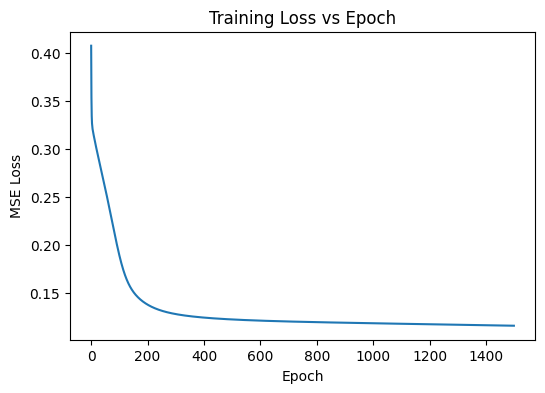


Train Accuracy: 92.06%
Test Accuracy: 87.65%


In [7]:
# F. Training
lr = 0.20
epochs = 1500
N_train = X_train.shape[0]

losses = []

for epoch in range(epochs):
    # Forward pass
    Z1, A1, Y = forward(X_train, W1, b1, W2, b2)
    
    # Compute Loss (MSE)
    loss = (1 / (2 * N_train)) * np.sum((Y - T_train) ** 2)
    losses.append(loss)
    
    # Backward pass
    dY = (1 / N_train) * (Y - T_train)
    
    dW2 = np.dot(A1.T, dY)
    db2 = np.sum(dY, axis=0, keepdims=True)
    
    dA1 = np.dot(dY, W2.T)
    dZ1 = dA1 * (A1 * (1 - A1))
    
    dW1 = np.dot(X_train.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    
    # Update parameters using full-batch gradient descent
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    
    # Print training loss every 100 epochs
    if epoch % 100 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:4d} | Loss: {loss:.5f}")

# Plot loss vs epoch
plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.show()

# G. Evaluate
def compute_accuracy(X, y_true, W1, b1, W2, b2):
    _, _, Y_pred = forward(X, W1, b1, W2, b2)
    # Compute accuracy using argmax on logits
    predictions = np.argmax(Y_pred, axis=1)
    accuracy = np.mean(predictions == y_true)
    return accuracy

train_acc = compute_accuracy(X_train, y_train, W1, b1, W2, b2)
test_acc = compute_accuracy(X_test, y_test, W1, b1, W2, b2)

# Print accuracies
print(f"\nTrain Accuracy: {train_acc * 100:.2f}%")
print(f"Test Accuracy: {test_acc * 100:.2f}%")